In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif, chi2
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/BRFSS_Diabetes_Cleaned.csv')
target = "has_diabetes"
features = [col for col in df.columns if col != target]
print(f"Total features: {len(features)}")

Total features: 104


## Diabetics

### Feature Identification (Binary and Numerical)

In [2]:
def is_byte_string_mess(series):
    # Check if any non-null value looks like "b'...'"
    sample = series.dropna().astype(str).head(10)
    return any(val.startswith("b'") and val.endswith("'") for val in sample)

messy_cols = [col for col in df.columns if is_byte_string_mess(df[col])]
print("Messy columns:", messy_cols)

for col in messy_cols:
    # Remove b'...' wrapper if present
    df[col] = df[col].astype(str).str.replace(r"^b'(.*)'$", r'\1', regex=True)
    
    # Optional: convert to numeric if appropriate (e.g., '01' → 1)
    # Only do this if the cleaned values are actually numbers!
    # Try converting; if it fails, keep as string (likely categorical)
    try:
        # If you want '01' to become 1 (integer):
        df[col] = pd.to_numeric(df[col], errors='coerce')
    except Exception:
        pass  # Keep as cleaned string

Messy columns: []


In [3]:
binary_features = []
numerical_features = []

for col in features:
    # Skip non-numeric columns entirely
    if not pd.api.types.is_numeric_dtype(df[col]):
        numerical_features.append(col)  # or handle separately if you have categorical features
        continue
    
    # Get unique non-null values
    unique_vals = df[col].dropna().unique()
    
    # Handle empty columns (all null)
    if len(unique_vals) == 0:
        numerical_features.append(col)
        continue
    
    # Round values to handle float precision issues (0.0, 1.0, etc.)
    try:
        rounded_vals = np.round(unique_vals, 6)
        if set(rounded_vals).issubset({0, 1}):
            binary_features.append(col)
        else:
            numerical_features.append(col)
    except (TypeError, ValueError):
        # Fallback for any remaining edge cases
        numerical_features.append(col)

print(f"Binary features: {len(binary_features)}")
print(f"Numerical features: {len(numerical_features)}")

Binary features: 80
Numerical features: 24


In [ ]:
# Ensure target has no missing values
df_complete = df.dropna(subset=[target]).copy()

# Clean numerical features
for col in numerical_features:
    # Coerce non-numeric strings (like 'Missing') to NaN
    df_complete[col] = pd.to_numeric(df_complete[col], errors='coerce')

# Impute binary features: fill missing with 0
X_bin = df_complete[binary_features].fillna(0)

# Impute numerical features: fill missing with median
X_num = df_complete[numerical_features].copy()
for col in numerical_features:
    X_num[col] = X_num[col].fillna(X_num[col].median())

# Target vector
y = df_complete[target]

print("Binary features shape:", X_bin.shape)
print("Numerical features shape:", X_num.shape)
print("Target shape:", y.shape)


Binary features shape: (364124, 80)
Numerical features shape: (364124, 24)
Target shape: (364124,)


### Chi-Square test


 Significant binary features (p < 0.01): 76

ALL SIGNIFICANT BINARY FEATURES (p < 0.01)
                                   feature  chi2_score   p_value
                       tested_for_diabetes    37492.00  0.00e+00
                              high_bp_risk    27143.52  0.00e+00
                               has_high_bp    25361.28  0.00e+00
                                   had_cvd    17534.18  0.00e+00
                   uses_exercise_equipment    16046.44  0.00e+00
      blood_sugar_checks_missing_indicator    14926.67  0.00e+00
                             vaccine_score    12383.74  0.00e+00
     tested_for_diabetes_missing_indicator    12271.96  0.00e+00
                   has_activity_limitation    12162.20  0.00e+00
                             has_arthritis    12017.80  0.00e+00
                        general_health_cat    11587.11  0.00e+00
                       general_health_risk    11587.11  0.00e+00
                              alcohol_user    11206.09  0.00e+00
 

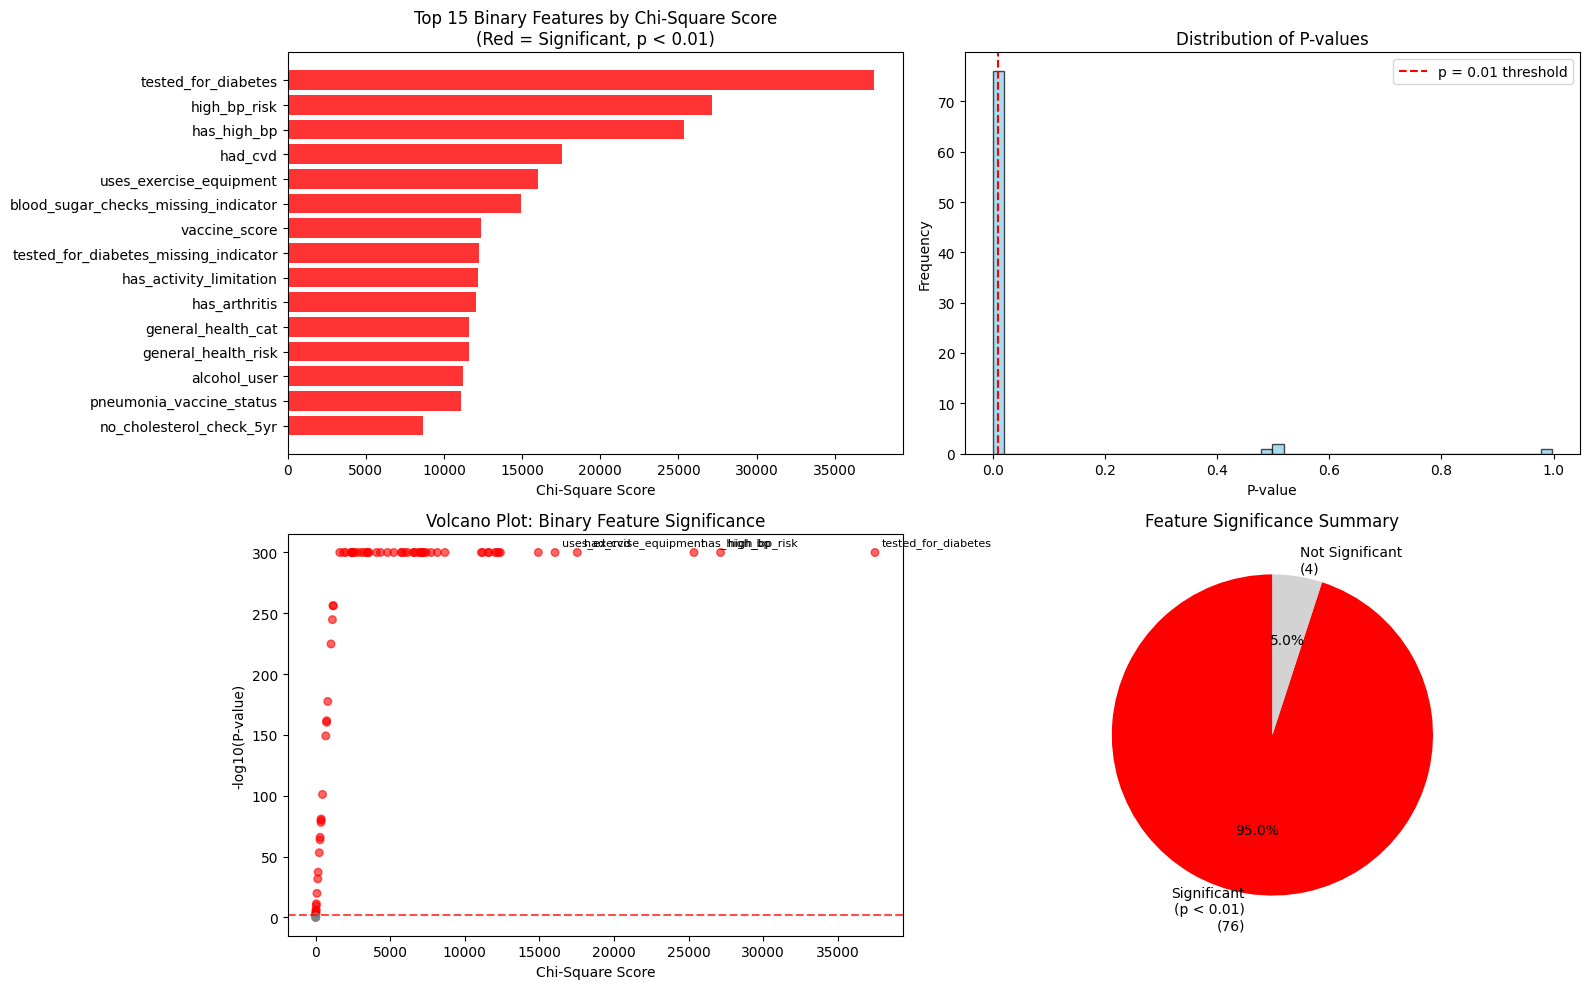


 Advanced visualization saved to: ../results/chi2_binary_analysis.png

 Final significant binary features for modeling (76):
 1. tested_for_diabetes
 2. high_bp_risk
 3. has_high_bp
 4. had_cvd
 5. uses_exercise_equipment
 6. blood_sugar_checks_missing_indicator
 7. vaccine_score
 8. tested_for_diabetes_missing_indicator
 9. has_activity_limitation
10. has_arthritis
11. general_health_cat
12. general_health_risk
13. alcohol_user
14. pneumonia_vaccine_status
15. no_cholesterol_check_5yr
16. had_pneumonia_vaccine
17. arthritis_social_limit
18. alcohol_days_year_missing_indicator
19. has_kidney_disease
20. avg_drinks_per_day_missing_indicator
21. arthritis_diagnosed
22. arthritis_social_limit_missing_indicator
23. is_binge_drinker
24. physical_health_bad
25. max_drinks_occasion_missing_indicator
26. join_pain_level_missing_indicator
27. arthritis_diagnosed_missing_indicator
28. has_high_cholesterol
29. pneumonia_vaccine_status_missing_indicator
30. heavy_drinker
31. has_strength_training

In [5]:
# Run Chi-Square test
try:
    chi2_scores, chi2_pvals = chi2(X_bin, y)
except ValueError as e:
    print(f"Chi2 error: {e}")
    # Fallback: manually compute for problematic features
    chi2_scores = []
    chi2_pvals = []
    for col in X_bin.columns:
        try:
            score, pval = chi2(X_bin[[col]], y)
            chi2_scores.append(score[0])
            chi2_pvals.append(pval[0])
        except:
            chi2_scores.append(0)
            chi2_pvals.append(1.0)

# Create results dataframe
chi2_results = pd.DataFrame({
    'feature': X_bin.columns,
    'chi2_score': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('chi2_score', ascending=False)

# Add significance flag
chi2_results['significant'] = chi2_results['p_value'] < 0.01

# Get significant features
significant_binary = chi2_results[chi2_results['significant']]['feature'].tolist()
print(f"\n Significant binary features (p < 0.01): {len(significant_binary)}")

# Display ALL significant features
if significant_binary:
    print("\n" + "="*80)
    print("ALL SIGNIFICANT BINARY FEATURES (p < 0.01)")
    print("="*80)
    significant_df = chi2_results[chi2_results['significant']].copy()
    # Format for better readability
    significant_df['chi2_score'] = significant_df['chi2_score'].round(2)
    significant_df['p_value'] = significant_df['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
    print(significant_df[['feature', 'chi2_score', 'p_value']].to_string(index=False))
else:
    print("No significant binary features found!")

# Save results to CSV
chi2_results.to_csv('../results/chi2_binary_features.csv', index=False)
print(f"\n Chi-Square results saved to: ../results/chi2_binary_features.csv")

# Advanced Visualization
plt.figure(figsize=(16, 10))

# Plot 1: Top 15 features by Chi2 score
plt.subplot(2, 2, 1)
top_15 = chi2_results.head(15)
colors = ['red' if sig else 'lightgray' for sig in top_15['significant']]
bars = plt.barh(range(len(top_15)), top_15['chi2_score'], color=colors, alpha=0.8)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Chi-Square Score')
plt.title('Top 15 Binary Features by Chi-Square Score\n(Red = Significant, p < 0.01)')
plt.gca().invert_yaxis()

# Plot 2: P-value distribution
plt.subplot(2, 2, 2)
plt.hist(chi2_results['p_value'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='p = 0.01 threshold')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.legend()

# Plot 3: Volcano plot (Chi2 score vs -log10(p-value))
plt.subplot(2, 2, 3)
chi2_results_plot = chi2_results.copy()
chi2_results_plot['neg_log10_pval'] = -np.log10(chi2_results_plot['p_value'].clip(lower=1e-300))  # Avoid log(0)
colors = ['red' if sig else 'gray' for sig in chi2_results_plot['significant']]

plt.scatter(chi2_results_plot['chi2_score'], chi2_results_plot['neg_log10_pval'], 
           c=colors, alpha=0.6, s=30)
plt.xlabel('Chi-Square Score')
plt.ylabel('-log10(P-value)')
plt.title('Volcano Plot: Binary Feature Significance')
plt.axhline(-np.log10(0.01), color='red', linestyle='--', alpha=0.7)

# Add labels for top significant features
top_sig = chi2_results_plot[chi2_results_plot['significant']].nlargest(5, 'chi2_score')
for idx, row in top_sig.iterrows():
    plt.annotate(row['feature'], (row['chi2_score'], row['neg_log10_pval']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 4: Feature significance summary
plt.subplot(2, 2, 4)
total_features = len(chi2_results)
significant_count = len(significant_binary)
non_significant = total_features - significant_count

plt.pie([significant_count, non_significant], 
        labels=[f'Significant\n(p < 0.01)\n({significant_count})', 
                f'Not Significant\n({non_significant})'],
        colors=['red', 'lightgray'], autopct='%1.1f%%', startangle=90)
plt.title('Feature Significance Summary')

plt.tight_layout()
plt.savefig('../results/chi2_binary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Advanced visualization saved to: ../results/chi2_binary_analysis.png")

# Final feature list for modeling
print(f"\n Final significant binary features for modeling ({len(significant_binary)}):")
for i, feature in enumerate(significant_binary, 1):
    print(f"{i:2}. {feature}")

### ANOVA F-test


 Significant numerical features (p < 0.01): 24

ALL SIGNIFICANT NUMERICAL FEATURES (p < 0.01)
                    feature  f_score   p_value
                    age_cat 48467.86  0.00e+00
chronic_conditions_standard 41481.03  0.00e+00
                        BMI 39857.94  0.00e+00
         blood_sugar_checks 24794.52  0.00e+00
            join_pain_level 20818.30  0.00e+00
cholesterol_screening_score 18472.32  0.00e+00
          alcohol_days_year 12147.90  0.00e+00
        max_drinks_occasion 12146.03  0.00e+00
            education_level  9458.85  0.00e+00
         avg_drinks_per_day  8662.18  0.00e+00
          care_access_score  7910.83  0.00e+00
    total_activity_duration  4986.43  0.00e+00
            time_since_quit  4665.36  0.00e+00
        total_exercise_freq  4447.38  0.00e+00
               income_group  3250.22  0.00e+00
              hiv_test_year  2526.81  0.00e+00
       usual_drinks_per_day  2099.80  0.00e+00
          total_fv_servings  1101.96 2.85e-241
         tot

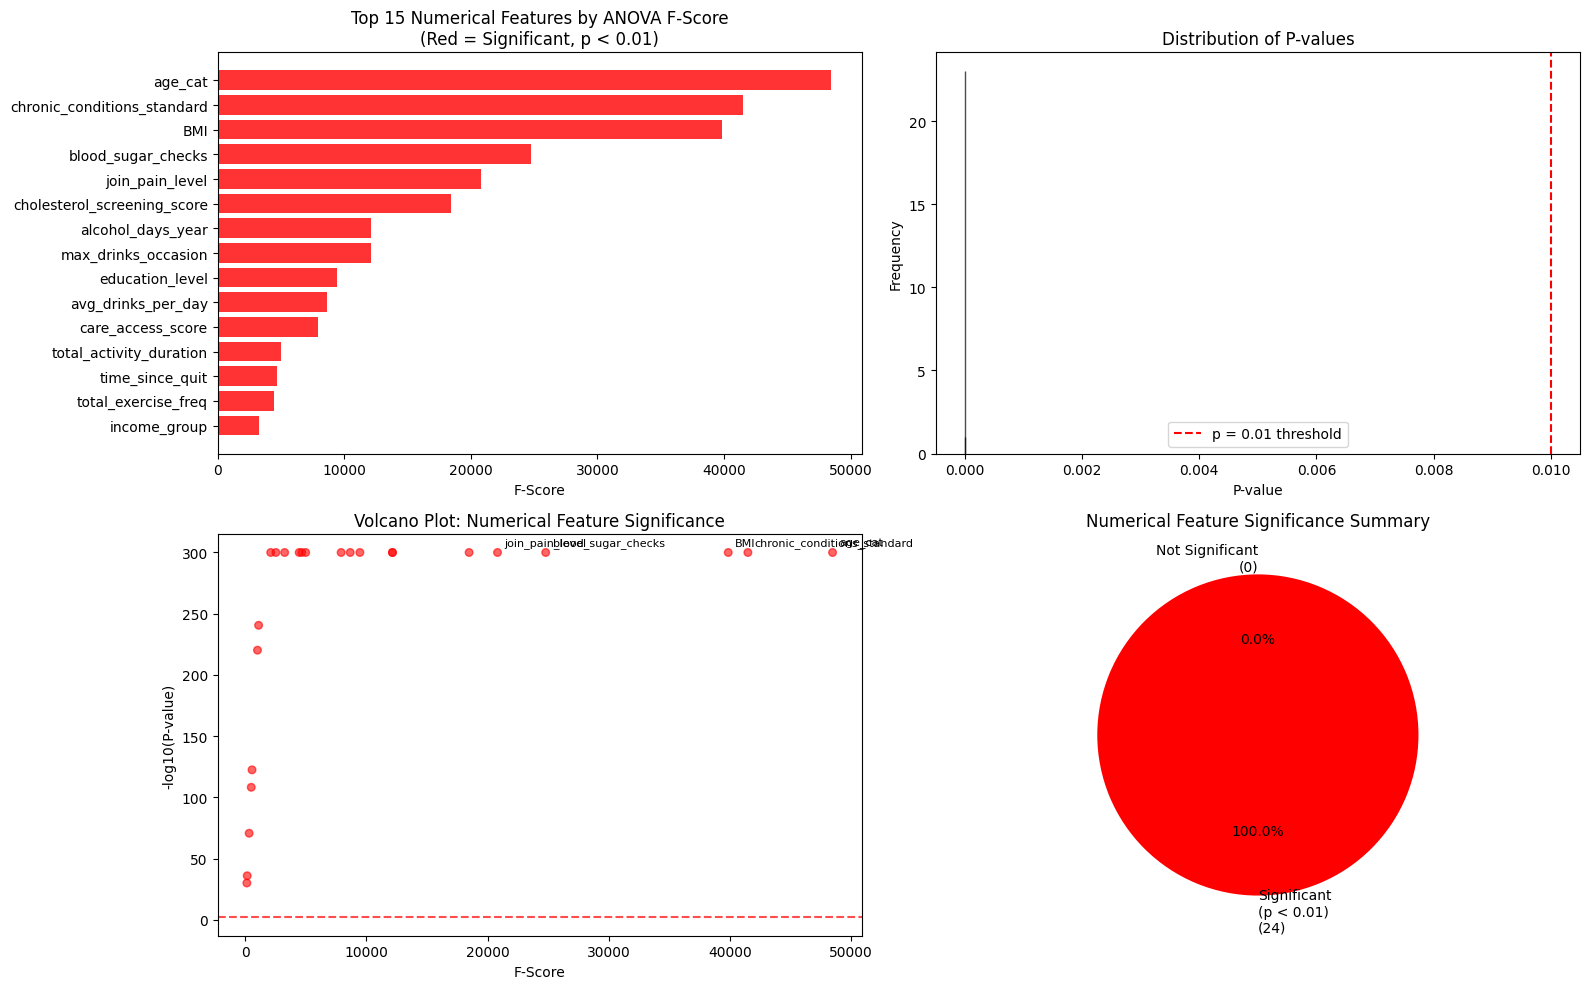


 Advanced visualization saved to: ../results/anova_numerical_analysis.png

 Final significant numerical features for modeling (24):
 1. age_cat
 2. chronic_conditions_standard
 3. BMI
 4. blood_sugar_checks
 5. join_pain_level
 6. cholesterol_screening_score
 7. alcohol_days_year
 8. max_drinks_occasion
 9. education_level
10. avg_drinks_per_day
11. care_access_score
12. total_activity_duration
13. time_since_quit
14. total_exercise_freq
15. income_group
16. hiv_test_year
17. usual_drinks_per_day
18. total_fv_servings
19. total_veg_servings
20. juice_servings_day
21. total_fruit_servings
22. drinks_per_day
23. fruit_servings_day
24. smoking_status


In [6]:
# Run ANOVA F-test
try:
    f_scores, f_pvals = f_classif(X_num, y)
except ValueError as e:
    print(f"ANOVA error: {e}")
    # Fallback: compute feature by feature
    f_scores = []
    f_pvals = []
    for col in X_num.columns:
        try:
            score, pval = f_classif(X_num[[col]], y)
            f_scores.append(score[0])
            f_pvals.append(pval[0])
        except:
            f_scores.append(0)
            f_pvals.append(1.0)

# Create results dataframe
anova_results = pd.DataFrame({
    'feature': X_num.columns,
    'f_score': f_scores,
    'p_value': f_pvals
}).sort_values('f_score', ascending=False)

# Handle infinite F-scores (perfect separation)
anova_results['f_score'] = anova_results['f_score'].replace([np.inf, -np.inf], 1e6)

# Add significance flag
anova_results['significant'] = anova_results['p_value'] < 0.01

# Remove target leakage features (CRITICAL!)
leakage_features = ['DIABETE3', 'PREDIAB1', 'INSULIN', 'CHKHEMO3', 'DOCTDIAB', 'DIABAGE2']
leakage_in_results = [f for f in leakage_features if f in anova_results['feature'].values]
if leakage_in_results:
    print(f"  Removing target leakage features: {leakage_in_results}")
    anova_results = anova_results[~anova_results['feature'].isin(leakage_features)]

# Get significant features
significant_numerical = anova_results[anova_results['significant']]['feature'].tolist()
print(f"\n Significant numerical features (p < 0.01): {len(significant_numerical)}")

# Display ALL significant features
if significant_numerical:
    print("\n" + "="*80)
    print("ALL SIGNIFICANT NUMERICAL FEATURES (p < 0.01)")
    print("="*80)
    significant_df = anova_results[anova_results['significant']].copy()
    # Format for better readability
    significant_df['f_score'] = significant_df['f_score'].apply(lambda x: f"{x:.2f}" if x < 1e5 else "inf")
    significant_df['p_value'] = significant_df['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
    print(significant_df[['feature', 'f_score', 'p_value']].to_string(index=False))
else:
    print("No significant numerical features found!")

# Save results to CSV
anova_results.to_csv('../results/anova_numerical_features.csv', index=False)
print(f"\n ANOVA results saved to: ../results/anova_numerical_features.csv")

# Advanced Visualization
plt.figure(figsize=(16, 10))

# Plot 1: Top 15 features by F-score
plt.subplot(2, 2, 1)
top_15 = anova_results.head(15)
colors = ['red' if sig else 'lightgray' for sig in top_15['significant']]
bars = plt.barh(range(len(top_15)), top_15['f_score'], color=colors, alpha=0.8)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('F-Score')
plt.title('Top 15 Numerical Features by ANOVA F-Score\n(Red = Significant, p < 0.01)')
plt.gca().invert_yaxis()

# Plot 2: P-value distribution
plt.subplot(2, 2, 2)
plt.hist(anova_results['p_value'], bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='p = 0.01 threshold')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.legend()

# Plot 3: Volcano plot (F-score vs -log10(p-value))
plt.subplot(2, 2, 3)
anova_plot = anova_results.copy()
anova_plot['neg_log10_pval'] = -np.log10(anova_plot['p_value'].clip(lower=1e-300))
colors = ['red' if sig else 'gray' for sig in anova_plot['significant']]

plt.scatter(anova_plot['f_score'], anova_plot['neg_log10_pval'], 
           c=colors, alpha=0.6, s=30)
plt.xlabel('F-Score')
plt.ylabel('-log10(P-value)')
plt.title('Volcano Plot: Numerical Feature Significance')
plt.axhline(-np.log10(0.01), color='red', linestyle='--', alpha=0.7)

# Add labels for top significant features
top_sig = anova_plot[anova_plot['significant']].nlargest(5, 'f_score')
for idx, row in top_sig.iterrows():
    plt.annotate(row['feature'], (row['f_score'], row['neg_log10_pval']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 4: Feature significance summary
plt.subplot(2, 2, 4)
total_features = len(anova_results)
significant_count = len(significant_numerical)
non_significant = total_features - significant_count

plt.pie([significant_count, non_significant], 
        labels=[f'Significant\n(p < 0.01)\n({significant_count})', 
                f'Not Significant\n({non_significant})'],
        colors=['red', 'lightgray'], autopct='%1.1f%%', startangle=90)
plt.title('Numerical Feature Significance Summary')

plt.tight_layout()
plt.savefig('../results/anova_numerical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Advanced visualization saved to: ../results/anova_numerical_analysis.png")

# Final feature list for modeling
print(f"\n Final significant numerical features for modeling ({len(significant_numerical)}):")
for i, feature in enumerate(significant_numerical, 1):
    print(f"{i:2}. {feature}")


## Total Time = 14.4S